# Image Optimizer Notebook

Supports:
- JPEG, PNG, WebP, BMP, TIFF input
- Resize while preserving aspect ratio
- Target maximum dimensions
- Target maximum file size
- JPEG/WebP binary-search quality optimization
- PNG palette optimization


In [1]:
!pip install pillow


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from PIL import Image, ImageEnhance
from pathlib import Path
import io, os

# ==========================
# USER CONFIGURATION
# ==========================

INPUT_IMAGE = r"D:\Extension\Extension\images\Product 2\488.jpeg"  # Input image path
OUTPUT_FORMAT = "same"     # same, jpeg, png, webp

MAX_WIDTH = 333
MAX_HEIGHT = 500

TARGET_SIZE_KB = 30

RESIZE = True
COMPRESS = True
KEEP_ASPECT = True  # Set False to force exact size
USE_WHITE_BACKGROUND = True
WHITE_BACKGROUND_COLOR = (255, 255, 255)

JPEG_MIN_QUALITY = 20
JPEG_MAX_QUALITY = 95

WEBP_MIN_QUALITY = 20
WEBP_MAX_QUALITY = 95

# Set values < 1.0 to reduce sharpness/contrast, > 1.0 to increase
SHARPNESS_FACTOR = 1.25
CONTRAST_FACTOR = 0.80



In [3]:
def file_size_kb(path):
    return os.path.getsize(path)/1024

def image_info(path):
    img = Image.open(path)
    return {
        "format": img.format,
        "mode": img.mode,
        "width": img.width,
        "height": img.height,
        "size_kb": file_size_kb(path)
    }

def print_info(title, info):
    print("="*40)
    print(title)
    for k,v in info.items():
        print(f"{k:10}: {v}")


In [4]:
def resize_image(img):
    if not RESIZE:
        return img

    if KEEP_ASPECT:
        img.thumbnail((MAX_WIDTH, MAX_HEIGHT), Image.LANCZOS)
        return img

    return img.resize((MAX_WIDTH, MAX_HEIGHT), Image.LANCZOS)


In [5]:
def save_jpeg(img, output, target_kb):
    if img.mode in ("RGBA","LA","P"):
        img = img.convert("RGB")

    low = JPEG_MIN_QUALITY
    high = JPEG_MAX_QUALITY
    best = None

    while low <= high:
        q = (low + high)//2
        buf = io.BytesIO()

        img.save(buf,
                 format="JPEG",
                 quality=q,
                 optimize=False)

        size = len(buf.getvalue())/1024

        if size <= target_kb:
            best = buf.getvalue()
            low = q + 1
        else:
            high = q - 1

    if best is None:
        buf = io.BytesIO()
        img.save(buf,
                 format="JPEG",
                 quality=JPEG_MIN_QUALITY,
                 optimize=False)
        best = buf.getvalue()

    with open(output,"wb") as f:
        f.write(best)


In [6]:
def save_webp(img, output, target_kb):
    low = WEBP_MIN_QUALITY
    high = WEBP_MAX_QUALITY
    best = None

    while low <= high:
        q = (low+high)//2

        buf = io.BytesIO()
        img.save(buf,
                 format="WEBP",
                 quality=q,
                 method=6)

        size = len(buf.getvalue())/1024

        if size <= target_kb:
            best = buf.getvalue()
            low = q + 1
        else:
            high = q - 1

    if best is None:
        buf = io.BytesIO()
        img.save(buf,
                 format="WEBP",
                 quality=WEBP_MIN_QUALITY,
                 method=6)
        best = buf.getvalue()

    with open(output,"wb") as f:
        f.write(best)


In [7]:
def save_png(img, output, target_kb):

    # palette_sizes = [256,128,64,32,16,8,4]
    palette_sizes = [256,128,64,32]

    best = None

    for colors in palette_sizes:

        test = img.convert(
            "P",
            palette=Image.ADAPTIVE,
            colors=colors
        )

        buf = io.BytesIO()

        test.save(buf,
                  format="PNG",
                  optimize=True,
                  compress_level=9)

        size = len(buf.getvalue())/1024

        best = buf.getvalue()

        if size <= target_kb:
            print(f"Achieved target size with {colors} colors.")
            break

    with open(output,"wb") as f:
        f.write(best)


In [22]:
def optimize_image(input_path):

    def enhance_image(img):
        # if SHARPNESS_FACTOR != 1.0:
        enhancer = ImageEnhance.Sharpness(img)
        img = enhancer.enhance(SHARPNESS_FACTOR)

        # if CONTRAST_FACTOR != 1.0:
        # enhancer = ImageEnhance.Contrast(img)
        # img = enhancer.enhance(CONTRAST_FACTOR)

        return img

    def white_background(img):
        if img.mode != "RGBA":
            img = img.convert("RGBA")
        background = Image.new("RGBA", img.size, WHITE_BACKGROUND_COLOR + (255,))
        background.paste(img, mask=img.split()[3])
        return background.convert("RGB")

    info = image_info(input_path)
    print_info("Original", info)

    img = Image.open(input_path)

    img = resize_image(img)
    if USE_WHITE_BACKGROUND:
        img = white_background(img)
    img = enhance_image(img)

    fmt = OUTPUT_FORMAT.lower()

    if fmt == "same":
        fmt = info["format"].lower()

    output = Path(input_path).stem + "_optimized"

    if fmt in ("jpg","jpeg"):
        output += ".jpg"
        save_jpeg(img, output, TARGET_SIZE_KB)

    elif fmt == "png":
        output += ".png"
        save_png(img, output, TARGET_SIZE_KB)

    elif fmt == "webp":
        output += ".webp"
        save_webp(img, output, TARGET_SIZE_KB)

    else:
        raise ValueError(f"Unsupported output format: {fmt}")

    print()
    print_info("Optimized", image_info(output))

    reduction = (
        100
        * (1-file_size_kb(output)/info["size_kb"])
    )

    print(f"Reduction: {reduction:.2f}%")

    return output


Original
format    : JPEG
mode      : RGB
width     : 612
height    : 791
size_kb   : 92.2255859375

Optimized
format    : JPEG
mode      : RGB
width     : 333
height    : 430
size_kb   : 29.7158203125
Reduction: 67.78%
Saved: 488_optimized.jpg


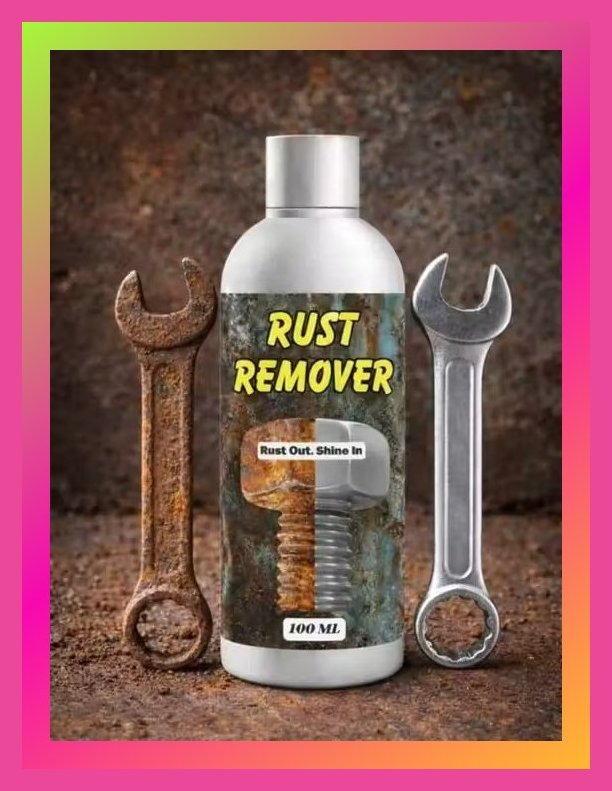

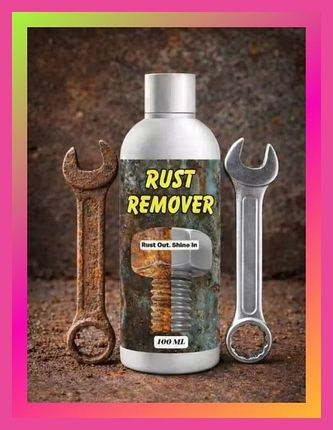

In [27]:
output = optimize_image(INPUT_IMAGE)
print("Saved:", output)

from IPython.display import display

display(Image.open(INPUT_IMAGE))
display(Image.open(output))


In [25]:
from PIL import Image

# Open the image
img = Image.open(r"D:\Extension\Extension\testing_img_compression\test_optimized.jpg").convert("RGB")

# Get color of the top-left corner pixel (x=0, y=0)
r, g, b = img.getpixel((0, 0))

# Convert RGB to HEX format
hex_color = f"#{r:02x}{g:02x}{b:02x}"

print(f"RGB Color: ({r}, {g}, {b})")
print(f"HEX Color: {hex_color.upper()}")

# Quick check if it's pure white
if hex_color.upper() == "#FFFFFF":
    print("The background is pure white.")
else:
    print("The background is NOT pure white.")

RGB Color: (255, 255, 255)
HEX Color: #FFFFFF
The background is pure white.
